In [8]:
import garpar as gp
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
mdo_inef = gp.datasets.make_risso_levy_stable(stocks=2, days=6, window_size=2, alpha=1.6411, beta=-0.0126, mu=0.005, sigma=0.005, entropy=0.01,
                                                     random_state=4)
mdo_inef

Stocks,"S0[W 1.0, H 0.01]","S1[W 1.0, H 0.01]"
Days,,
0,100.000000,100.000000
1,99.895061,99.909637
2,100.869914,101.379815
3,100.468472,101.258962
4,99.414927,101.165151
5,98.365654,100.808201
6,98.640144,102.674780


In [32]:
mdo_ef= gp.datasets.make_risso_levy_stable(stocks=2, days=6, window_size=2, alpha=1.6411, beta=-0.0126, mu=0.005, sigma=0.005, entropy=0.99,
                                   random_state=4)
mdo_ef

Stocks,"S0[W 1.0, H 0.99]","S1[W 1.0, H 0.99]"
Days,,
0,100.000000,100.000000
1,100.975877,101.851615
2,101.257651,102.484750
3,101.151392,101.403076
4,100.748831,102.330075
5,99.692345,102.686904
6,101.159326,102.880065


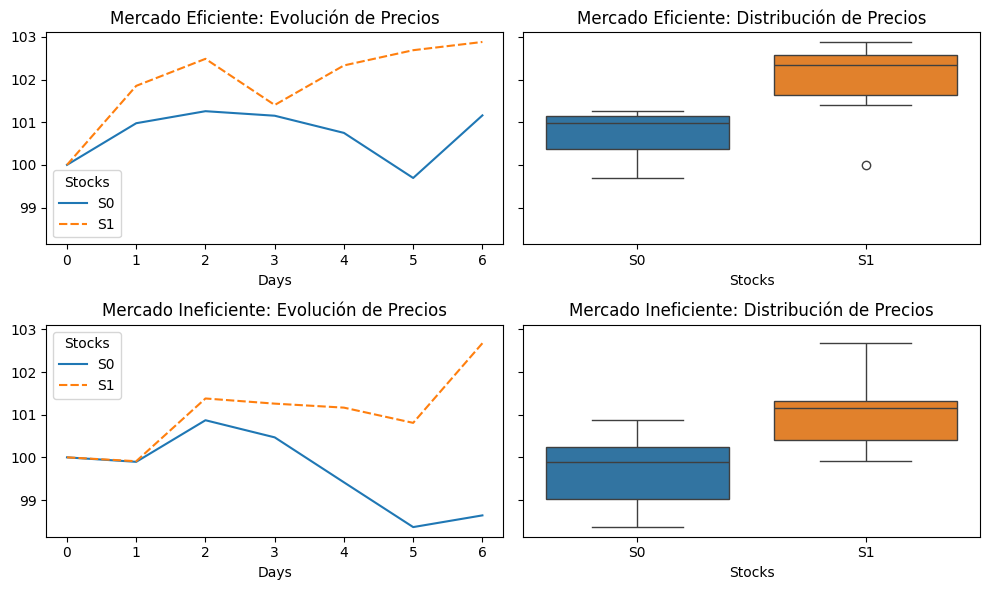

In [34]:
# Configuramos la figura de 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# --- MERCADO EFICIENTE (Entropía 0.99) ---
# Gráfico de Línea (Precios)
mdo_ef.plot.line(ax=axes[0, 0])
axes[0, 0].set_title("Mercado Eficiente: Evolución de Precios")

# Gráfico de Caja (Distribución)
mdo_ef.plot.box(ax=axes[0, 1])
axes[0, 1].set_title("Mercado Eficiente: Distribución de Precios")

# --- MERCADO INEFICIENTE (Entropía 0.01) ---
# Gráfico de Línea (Precios)
mdo_inef.plot.line(ax=axes[1, 0])
axes[1, 0].set_title("Mercado Ineficiente: Evolución de Precios")

# Gráfico de Caja (Distribución)
mdo_inef.plot.box(ax=axes[1, 1])
axes[1, 1].set_title("Mercado Ineficiente: Distribución de Precios")

# Ajuste estético
plt.tight_layout()
plt.savefig('imgs/mdo_efic_vs_inef.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
mk_st_return = gp.optimize.mean_variance.Markowitz(target_return=0.02)
mk_st_return.optimize(mdo_inef).weights

Stocks
S0    0.583221
S1    0.416779
Name: Weights, dtype: float64

In [13]:
mk_st_return = gp.optimize.mean_variance.Markowitz(target_return=0.02)
mk_st_return.optimize(mdo_ef).weights

Stocks
S0    0.988334
S1    0.011666
Name: Weights, dtype: float64

In [38]:
mefopt= mk_st_return.optimize(mdo_ef).weights_prune()
rows= []
rows.append({
        "Num stocks": len(mefopt.stocks),
        "Ent cruzada": mefopt.div.cross_entropy(),
        "Ent Zheng": mefopt.div.zheng_entropy(),
        "RD": mefopt.div.ratio(),
        "CV":(mefopt.div.mrc() *  mefopt.weights).std() / (mefopt.div.mrc() *  mefopt.weights).mean(),
        "PDI": mefopt.div.pdi(n_components=2, random_state=100)
    })
df_metrics = pd.DataFrame(rows)
df_metrics

,Num stocks,Ent cruzada,Ent Zheng,RD,CV,PDI
0,2,0.001133,0.692016,0.079811,0.067267,1.0
